# Trading strategy with Multinomial Logit

The multinomial logit is an extension of the logit model to accomodate more than one class. Assume there are K classes. For the first K-1 classes the model reads as:

$$
\Pr(Y=k\mid X=x)
=
\frac{e^{\beta_{k0}+\beta_{k1}x_1+\cdots+\beta_{kp}x_p}}
{1+\sum_{l=1}^{K-1} e^{\beta_{l0}+\beta_{l1}x_1+\cdots+\beta_{lp}x_p}},
\qquad k=1,\ldots,K-1,
$$
and for the K-th class:

$$
\Pr(Y=K\mid X=x)
=
\frac{1}
{1+\sum_{l=1}^{K-1} e^{\beta_{l0}+\beta_{l1}x_1+\cdots+\beta_{lp}x_p}}\,.
$$

We use the model to predict returns in three classes such that:

$$
y_i = \begin{cases}
0 & \text{Sell: if $r_{t-h, t} <0$},\\
1 & \text{Hold: if $0 > r_{t-h,t} < \bar{r}_{t-h,t}$},\\
2 & \text{Buy: if $r_{t-h,t}> \bar{r}_{t-h,t}$}.
\end{cases}
$$

The asset and sample are:
- Asset: 3M
- Sample: 1980 -- 2025 (train), 2025--2026 (test)


## 0. Required packages

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # DIsable parallel execution
os.environ["MKL_NUM_THREADS"] = "1" # Max threads for Intel MKL (Math Kernel Library)
os.environ["OPENBLAS_NUM_THREADS"] = "1" # Max threads for OpenBLAS 
os.environ["NUMEXPR_NUM_THREADS"] = "1" # threads for numexpr

import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pandas_datareader import data as pdr

## 1. Retrive data and create explanatory variables

We retrieve prices and trading volumes for `3M` from 1980-01-01 to 2026-01-01, and use 90% of the sample for training the model and the remaining 10% to test the trading strategy. Prices and volumes are downloaded from Yahoo Finance using `yfinance`.

As explanatory variables we include:
- Previous trading day return: $r_{t-1}$
- Returns three trading days ago: $r_{t-3}$
- Cumulative return between $t-6$ and $t-1$: $\sum_{t-6}^{t-1} r_t$
- Cumulative return between $t-11$ and $t-1$: $\sum_{t-11}^{t-1} r_t$
- Cumulative return between $t-21$ and $t-1$: $\sum_{t-21}^{t-1} r_t$
- Last 10 trading days returns volatility (annualized): $\sigma(r_{t-1}, r_{t-11}$
- Growth rate of trading volume: $\Delta Vol_{t}$

In [3]:
ticker = "MMM"
start = "1980-01-01"
end = "2026-01-01"
h = 5                      # horizon for labeling (future 5 trading days)
train_frac = 0.9

# -----------------------------
# 1) Download SPY (price + volume)
# -----------------------------
px = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)[["Close", "Volume"]].dropna()
px.columns = ["P", "VOL"]

ret = np.log(px["P"]).diff()

# -----------------------------
# 2) Create labels: BUY / HOLD / SELL based on forward h-day return
#    Use TRAIN quantiles to set thresholds (keeps classes reasonably balanced).
# -----------------------------
fwd_ret = np.log(px["P"]).shift(-h) - np.log(px["P"])   # forward h-day log return
df = pd.DataFrame(index=px.index)

df["fwd"] = fwd_ret
df["r1"] = ret.shift(1)
df["r3"] = ret.shift(3)
df["r5"] = ret.rolling(5).sum().shift(1)
df["r10"] = ret.rolling(10).sum().shift(1)
df["r20"] = ret.rolling(20).sum().shift(1)
df["vol10"] = ret.rolling(10).std().shift(1) * np.sqrt(252)   # annualized realized vol (lagged)
df["dlogvol"] = np.log(px["VOL"]).diff().shift(1)             # volume growth (lagged)

df = df.dropna()

# time split
split = int(len(df) * train_frac)
train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

## 2. Create classes

The dependend variable includes three classes:
- Buy
- Hold
- Sell

such that:

$$
y_i = \begin{cases}
0 & \text{Sell: if $r_{t-h, t} <0$},\\
1 & \text{Hold: if $0 > r_{t-h,t} < \bar{r}_{t-h,t}$},\\
2 & \text{Buy: if $r_{t-h,t}> \bar{r}_{t-h,t}$}.
\end{cases}
$$
where $\bar{r}_{t-h,t}$ is the median return over the last $h=5$ trading days


In [4]:
# thresholds from Sample (33/67 percentiles)
lo = 0
hi = np.median(df['fwd'])

# Encode classes: 0=SELL, 1=HOLD, 2=BUY
def label(x):
    if x <= lo:
        return 0
    elif x >= hi:
        return 2
    else:
        return 1

train["Y"] = train["fwd"].apply(label).astype(int)
test["Y"] = test["fwd"].apply(label).astype(int)

print("Train class shares (0=SELL,1=HOLD,2=BUY):")
print(train["Y"].value_counts(normalize=True).sort_index().round(3))
print("\nTest class shares (0=SELL,1=HOLD,2=BUY):")
print(test["Y"].value_counts(normalize=True).sort_index().round(3))

Train class shares (0=SELL,1=HOLD,2=BUY):
Y
0    0.460
1    0.034
2    0.506
Name: proportion, dtype: float64

Test class shares (0=SELL,1=HOLD,2=BUY):
Y
0    0.513
1    0.037
2    0.449
Name: proportion, dtype: float64


## 3. Fit the model

Multinomial logit can be estimated using the `statsmodels` function `MNLogit`. Recall that the interpretation of the coefficients is always relative to the K-th class. `MNLogit` uses class 0=SELL as baseline. By changing the order one can express the coefficients relative the preferred class. 

For example:

`mapping = {2: 0, 0: 1, 1: 2}`

`y_new = y.map(mapping)`


A good practice when variables are on very different scales (levels, growth rates, cumulative, ...) is to normalize the variables. In practice for each variable $x_t$ we compute:

$$
\tilde{x}_t = \frac{x_t - \bar{x}_t}{\sigma(x_t)}
$$

In [5]:
# -----------------------------
# 3) Fit multinomial logit on lagged predictors
# -----------------------------
Xcols = ["r1","r3", "r5", "r10", "r20", "vol10", "dlogvol"]

# standardize using TRAIN moments (helps convergence / interpretability)
mu = train[Xcols].mean()
sd = train[Xcols].std().replace(0, 1.0)

X_tr = (train[Xcols] - mu) / sd
X_te = (test[Xcols] - mu) / sd

X_tr = sm.add_constant(X_tr, has_constant="add")
X_te = sm.add_constant(X_te, has_constant="add")

y_tr = train["Y"]
y_te = test["Y"]

mnl = sm.MNLogit(y_tr, X_tr).fit(disp=1, maxiter=200, method="newton")
print("\n=== Multinomial Logit (train) ===")
print(mnl.summary())


Optimization terminated successfully.
         Current function value: 0.813856
         Iterations 8

=== Multinomial Logit (train) ===
                          MNLogit Regression Results                          
Dep. Variable:                      Y   No. Observations:                10412
Model:                        MNLogit   Df Residuals:                    10396
Method:                           MLE   Df Model:                           14
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                0.003722
Time:                        13:16:38   Log-Likelihood:                -8473.9
converged:                       True   LL-Null:                       -8505.5
Covariance Type:            nonrobust   LLR p-value:                 3.041e-08
       Y=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6679      0.059    -45.271      0.000      -2.783      -

## 4. Out-of-sample and accuracy

First of all we predict the majority class $\hat{y}_t$ using OOS observations and compute the accuracy as the fraction of observation where the predicted class coincides with the true one. 

Second, we use the function `crosstab` from `pandas` to compute the confusion matrix. The latter tells us the model accuracy for each class and the misclassified predictions

In [6]:
# -----------------------------
# 4) Out-of-sample prediction + evaluation
# -----------------------------
p_te = mnl.predict(X_te)               # probs for classes 0/1/2
yhat = p_te.values.argmax(axis=1)

acc = (yhat == y_te.values).mean()
print("\nTest accuracy:", round(float(acc), 4))

# majority-class baseline (often strong if HOLD dominates)
maj = int(y_tr.value_counts().idxmax())
acc_maj = (y_te.values == maj).mean()
print("Majority-class baseline accuracy:", round(float(acc_maj), 4), "(predict", maj, "always)")

cm = pd.crosstab(pd.Series(y_te.values, name="Actual"),
                 pd.Series(yhat, name="Pred"),
                 normalize="index")
print("\nConfusion matrix (row-normalized):")
print(cm.round(3))

# balanced accuracy (mean recall across classes)
recall = np.diag(cm.reindex(index=[0,1,2], columns=[0,1,2], fill_value=0).values)
bal_acc = recall.mean()
print("\nBalanced accuracy (mean class recall):", round(float(bal_acc), 4))



Test accuracy: 0.4572
Majority-class baseline accuracy: 0.4494 (predict 2 always)

Confusion matrix (row-normalized):
Pred        0      2
Actual              
0       0.178  0.822
1       0.163  0.837
2       0.187  0.813

Balanced accuracy (mean class recall): 0.3306


## 5. Plot predicted vs. correct classes

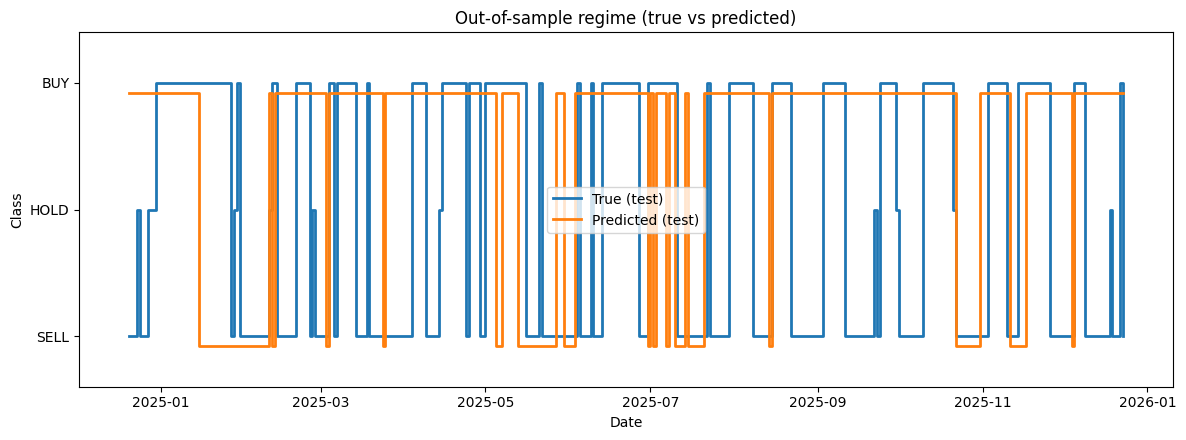

In [7]:
# -----------------------------
# 6) Plot out-of-sample class path (true vs predicted)
# -----------------------------
y_true = y_te.copy()  # has the test index
y_pred = pd.Series(yhat, index=y_true.index, name="Yhat")

# map classes to a signal axis: SELL=-1, HOLD=0, BUY=+1
sig_map = {0: -1, 1: 0, 2: 1}
true_sig = y_true.map(sig_map).astype(float)
pred_sig = y_pred.map(sig_map).astype(float)

# choose a window so the plot is readable (e.g., last 252 trading days)
window = 252
true_plot = true_sig.iloc[-window:]
pred_plot = pred_sig.iloc[-window:]

# small vertical offset so the two lines don't sit exactly on top of each other
pred_plot_off = pred_plot - 0.08

plt.figure(figsize=(12, 4.5))
plt.step(true_plot.index, true_plot.values, where="post", linewidth=2, label="True (test)")
plt.step(pred_plot_off.index, pred_plot_off.values, where="post", linewidth=2, label="Predicted (test)")

plt.yticks([-1, 0, 1], ["SELL", "HOLD", "BUY"])
plt.ylim(-1.4, 1.4)
plt.title("Out-of-sample regime (true vs predicted)")
plt.xlabel("Date")
plt.ylabel("Class")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Plot accuracy

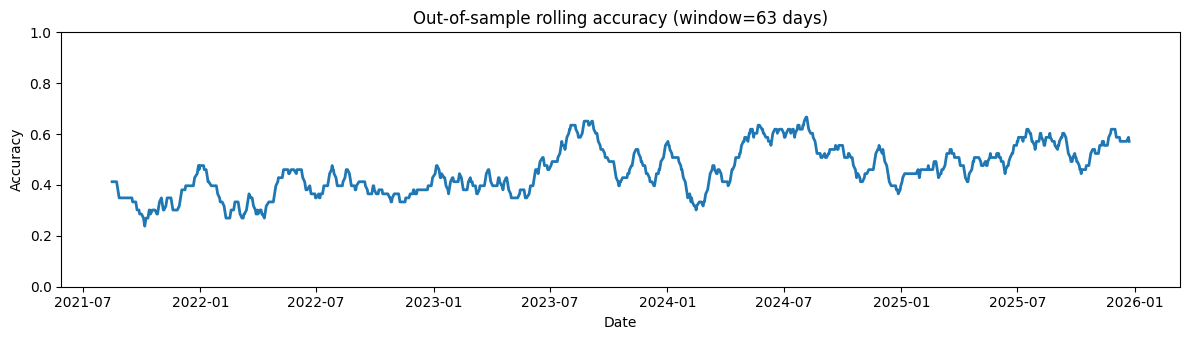

In [8]:
# Optional: rolling out-of-sample accuracy line (e.g., 3-month window)
roll = 63
roll_acc = (y_true == y_pred).rolling(roll).mean()
plt.figure(figsize=(12, 3.5))
plt.plot(roll_acc.index, roll_acc.values, linewidth=2)
plt.ylim(0, 1)
plt.title(f"Out-of-sample rolling accuracy (window={roll} days)")
plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 7. Trading strategy backtest

After predicting classes we test the performance of the implied trading strategy on the test sample. We assume the following:

- 2=BUY  -> invest in asset:      r = r_asset
- 1=HOLD -> invest in risk-free:  r = r_f
- 0=SELL -> short asset + invest proceeds at rf: r = r_f - r_asset

The risk-free rate is retrieved from `fred` using `prd.DataReader`.

We compare our trading strategy with a Buy-and-hold strategy (we buy the asset and keep it without trading). 

Performance is evaluated using different statistics:
- Total return
- Compound Annual Growth Rate (CAGR)
- Annual volatility
- Sharpe ratio
- Max Drawdown (Peak vs. Trough)

              Buy&Hold  Model (Buy/Hold/Sell w/ rf)
Total Return    0.1263                       0.1757
CAGR            0.0263                       0.0359
Ann.Vol         0.2815                       0.2815
Sharpe          0.2302                       0.2633
MaxDD          -0.5407                      -0.5480

Action shares (SELL/HOLD/BUY):
Yhat
SELL    0.182
BUY     0.818
Name: proportion, dtype: float64


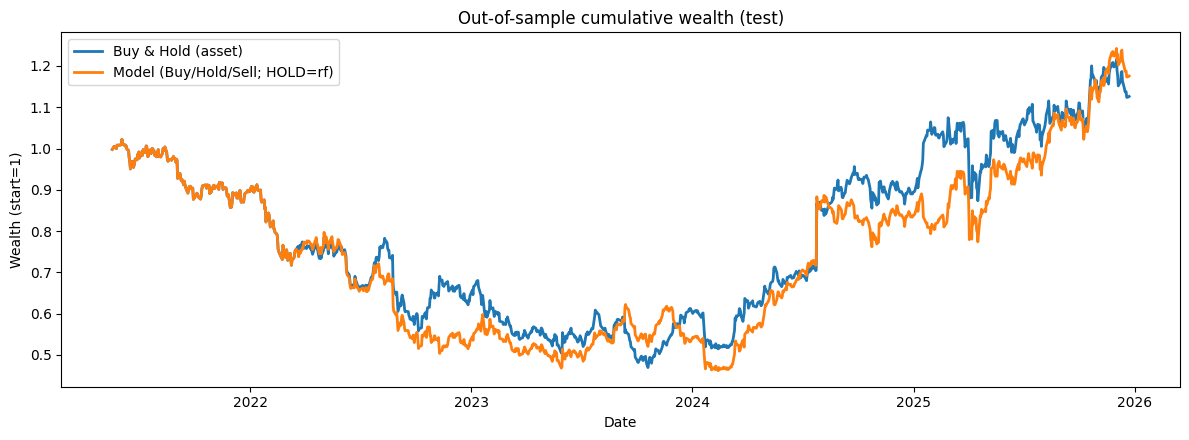

In [9]:
# -----------------------------
# 1) Asset next-day return (t -> t+1)
# -----------------------------
r_asset = px["P"].pct_change().shift(-1).reindex(test.index).dropna()

# -----------------------------
# 2) Daily risk-free return from FRED (approx)
#    DGS3MO is annualized percent; convert to daily decimal return ~ rate/100/252
# -----------------------------
start = str(r_asset.index.min().date())
end = str(r_asset.index.max().date())

rf = pdr.DataReader("DGS3MO", "fred", start, end).dropna()
r_f = (rf["DGS3MO"] / 100.0 / 252.0).rename("r_f")


# align rf to trading days (forward-fill last available rate)
r_f = r_f.reindex(r_asset.index).ffill().fillna(0.0)

# -----------------------------
# 3) Predicted actions -> returns
#    2=BUY  -> invest in asset:      r = r_asset
#    1=HOLD -> invest in risk-free:  r = r_f
#    0=SELL -> short asset + invest proceeds at rf: r = r_f - r_asset
#    (ignores borrow fees / margin / rebates; fine for teaching)
# -----------------------------
y_pred = pd.Series(yhat, index=test.index, name="Yhat").reindex(r_asset.index)

r_strat = pd.Series(np.nan, index=r_asset.index, name="r_strat")
r_strat[y_pred == 2] = r_asset[y_pred == 2]
r_strat[y_pred == 1] = r_f[y_pred == 1]
r_strat[y_pred == 0] = (r_f - r_asset)[y_pred == 0]

# Benchmark: buy-and-hold same asset (always long)
r_bh = r_asset.rename("r_bh")

# Optional: transaction costs (bps per action change)
# tc_bps = 5
# action = y_pred.copy()
# turnover = (action != action.shift(1)).astype(float).fillna(0.0)
# r_strat = r_strat - (tc_bps / 10000.0) * turnover

# -----------------------------
# 4) Performance summary + plot
# -----------------------------
def perf(r, ann=252):
    r = r.dropna()
    w = (1 + r).cumprod()
    cagr = w.iloc[-1] ** (ann / len(r)) - 1
    vol = r.std() * np.sqrt(ann)
    sharpe = (r.mean() * ann) / vol if vol > 0 else np.nan
    dd = w / w.cummax() - 1
    return pd.Series({
        "Total Return": w.iloc[-1] - 1,
        "CAGR": cagr,
        "Ann.Vol": vol,
        "Sharpe": sharpe,
        "MaxDD": dd.min()
    })

out = pd.concat([perf(r_bh).rename("Buy&Hold"),
                 perf(r_strat).rename("Model (Buy/Hold/Sell w/ rf)")], axis=1)
print(out.round(4))

print("\nAction shares (SELL/HOLD/BUY):")
print(y_pred.value_counts(normalize=True).sort_index().rename(index={0:"SELL",1:"HOLD",2:"BUY"}).round(3))

w_bh = (1 + r_bh).cumprod()
w_ms = (1 + r_strat).cumprod()

plt.figure(figsize=(12, 4.5))
plt.plot(w_bh.index, w_bh.values, linewidth=2, label="Buy & Hold (asset)")
plt.plot(w_ms.index, w_ms.values, linewidth=2, label="Model (Buy/Hold/Sell; HOLD=rf)")
plt.title("Out-of-sample cumulative wealth (test)")
plt.xlabel("Date")
plt.ylabel("Wealth (start=1)")
plt.legend()
plt.tight_layout()
plt.show()
